In [1]:
"""
Bifurcation Detection — Regression Training Pipeline & Streaming Deployment
============================================================================

Model outputs TWO heads per window:
  • p_bifurc  : P(a bifurcation exists in this window)          — binary [0,1]
  • t_bifurc  : normalised timestep of bifurcation ∈ [0,1]      — regression
                (only meaningful / penalised when p_bifurc > 0)

Why two heads?
  Null windows have no meaningful regression target.  Penalising the timestep
  head on null samples would force the network to predict an arbitrary number,
  corrupting the gradient signal.  Instead the regression loss is gated by
  whether the window actually contains a bifurcation.

Normalised timestep convention
  t_norm = (bifurcation_absolute_timestep − window_start) / window_length
  So t_norm=0.0 → bifurcation at the very start of the window
     t_norm=1.0 → bifurcation at the very end

Streaming deployment
  A rolling window strides across incoming data. Each stride produces:
    • updated p_bifurc estimate
    • predicted absolute timestep of the bifurcation
  An alert fires when p_bifurc passes a configurable threshold, with
  hysteresis to avoid duplicate alerts.
"""

import numpy as np
import torch
from torch.utils.data import DataLoader

from bi_plot import plot_recordings
from bi_data_sim import make_synthetic_recordings
from bi_data_struct import recording_level_split, BifurcationWindowDataset
from bi_model import BifurcationRegressor, train,collate_nan_safe, evaluate, GatedBifurcationLoss
from bi_stream import StreamingBifurcationDetector

In [2]:
# ──────────────────────────────────────────────────────────────────────────────
# Demo
# ──────────────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\n")

# ── 1. Generate recordings and split by recording ─────────────────────
print("── Generating synthetic recordings ──")
all_recordings = make_synthetic_recordings(
    n_null=1000, n_positive=1000, num_params=4, depth=75, time_len=1048,seed=np.random.randint(1e6,size=1)
)
train_recs, val_recs, test_recs = recording_level_split(all_recordings)
print(f"  Train recordings: {len(train_recs)}  Val: {len(val_recs)}  Test: {len(test_recs)}\n")

Device: cuda

── Generating synthetic recordings ──
  Train recordings: 1400  Val: 300  Test: 300



In [3]:
# ── 2. Build window datasets ──────────────────────────────────────────
print("── Building window datasets ──")
WINDOW = 64
STRIDE = 16

train_ds = BifurcationWindowDataset(train_recs, window_len=WINDOW, stride=STRIDE, precursor_steps=64)
val_ds   = BifurcationWindowDataset(val_recs,   window_len=WINDOW, stride=STRIDE)
test_ds  = BifurcationWindowDataset(test_recs,  window_len=WINDOW, stride=STRIDE)

── Building window datasets ──
  Dataset: 86800 windows  (5576 positive = 6.4%)
  Dataset: 18600 windows  (580 positive = 3.1%)
  Dataset: 18600 windows  (632 positive = 3.4%)


In [4]:
# ── 3. Build and train model ──────────────────────────────────────────
print("── Training ──")
model = BifurcationRegressor(num_params=4).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Trainable parameters: {total_params:,}\n")

model = train(
    model, train_ds, val_ds, device,
    epochs=50,       # increase for real training
    batch_size=64,
    patience=10,
    save_path=None,  # set a path to save checkpoints
)

── Training ──
  Trainable parameters: 5,058,626

Epoch 001/50  | train loss=0.0787  det=0.0256  reg=0.0266  acc=0.956  t_mae=0.3119  || val loss=0.0100  det=0.0097  acc=0.997  t_mae=0.0178
Epoch 002/50  | train loss=0.0715  det=0.0238  reg=0.0238  acc=0.962  t_mae=0.2741  || val loss=0.0122  det=0.0086  acc=0.998  t_mae=0.0534
Epoch 003/50  | train loss=0.0716  det=0.0234  reg=0.0241  acc=0.963  t_mae=0.2786  || val loss=0.0108  det=0.0106  acc=0.986  t_mae=0.0170
Epoch 004/50  | train loss=0.0720  det=0.0235  reg=0.0242  acc=0.963  t_mae=0.2790  || val loss=0.0105  det=0.0092  acc=0.997  t_mae=0.0294
Epoch 005/50  | train loss=0.0702  det=0.0233  reg=0.0235  acc=0.963  t_mae=0.2716  || val loss=0.0129  det=0.0100  acc=0.996  t_mae=0.0668
Epoch 006/50  | train loss=0.0733  det=0.0236  reg=0.0248  acc=0.962  t_mae=0.2833  || val loss=0.0148  det=0.0112  acc=0.997  t_mae=0.0526
Epoch 007/50  | train loss=0.0706  det=0.0234  reg=0.0236  acc=0.962  t_mae=0.2772  || val loss=0.0097  det=0.

In [5]:
# ── 4. Test set evaluation ────────────────────────────────────────────
print("\n── Test set evaluation ──")
test_loader = DataLoader(
    test_ds, batch_size=64, collate_fn=collate_nan_safe 
)
criterion = GatedBifurcationLoss()
test_metrics = evaluate(model, test_loader, criterion, device)
print(
    f"  test loss={test_metrics['loss']:.4f}  "
    f"det_acc={test_metrics['det_acc']:.3f}  "
    f"timing_mae={test_metrics['timing_mae']:.4f} (normalised)"
)
print(
    f"  timing_mae in timesteps ≈ {test_metrics['timing_mae'] * WINDOW:.1f} / {WINDOW}"
)


── Test set evaluation ──
  test loss=0.0116  det_acc=0.997  timing_mae=0.0286 (normalised)
  timing_mae in timesteps ≈ 1.8 / 64


In [7]:
# ── 5. Streaming demo ─────────────────────────────────────────────────
print("\n── Streaming demo ──")
detector = StreamingBifurcationDetector(
    model, window_len=WINDOW, stride=STRIDE,
    threshold=0.55, cooldown_steps=32, ema_alpha=0.4, device=device,
)

# Pick a positive test recording and stream it in stride-sized chunks
pos_recs = [r for r in test_recs if r.is_positive]
if pos_recs:
    rec = pos_recs[0]
    print(f"  Streaming recording '{rec.recording_id}'  "
          f"(true bifurcation at t={rec.bifurcation_t}, "
          f"total T={rec.time_len})")

    for t in range(0, rec.time_len, STRIDE):
        chunk = rec.data[:, :, t : t + STRIDE]
        if chunk.shape[2] == 0:
            print("warning chunk wrong shape!")
            break
        alerts = detector.push(chunk)
        for alert in alerts:
            lead = alert.steps_until_bifurc
            lead_str = f"{lead:+d} steps" if lead >= 0 else f"{abs(lead)} steps AFTER"
            print(
                f"  🚨 ALERT  t={alert.absolute_timestep:4d}  "
                f"p={alert.p_bifurcation:.3f}  "
                f"predicted_t={alert.predicted_bifurc_t}  "
                f"lead={lead_str}"
            )
else:
    print("  (No positive recordings in test split — increase n_positive or use a fixed seed)")

print(f"Highlight: {rec.recording_id}")
print(f"  Actual bifurcation    : t={rec.bifurcation_t}")
print(f"  Prediction bifurcation  : t={alert.predicted_bifurc_t}")


── Streaming demo ──
  Streaming recording 'pos_0631'  (true bifurcation at t=558, total T=1048)
  🚨 ALERT  t= 576  p=0.591  predicted_t=559  lead=17 steps AFTER
Highlight: pos_0631
  Actual bifurcation    : t=558
  Prediction bifurcation  : t=559


  Saved → bifurcation_plot.png


(<Figure size 1400x1120 with 4 Axes>,
 array([<Axes: ylabel='Parameter 1'>, <Axes: ylabel='Parameter 2'>,
        <Axes: ylabel='Parameter 3'>,
        <Axes: xlabel='Timestep', ylabel='Parameter 4'>], dtype=object))

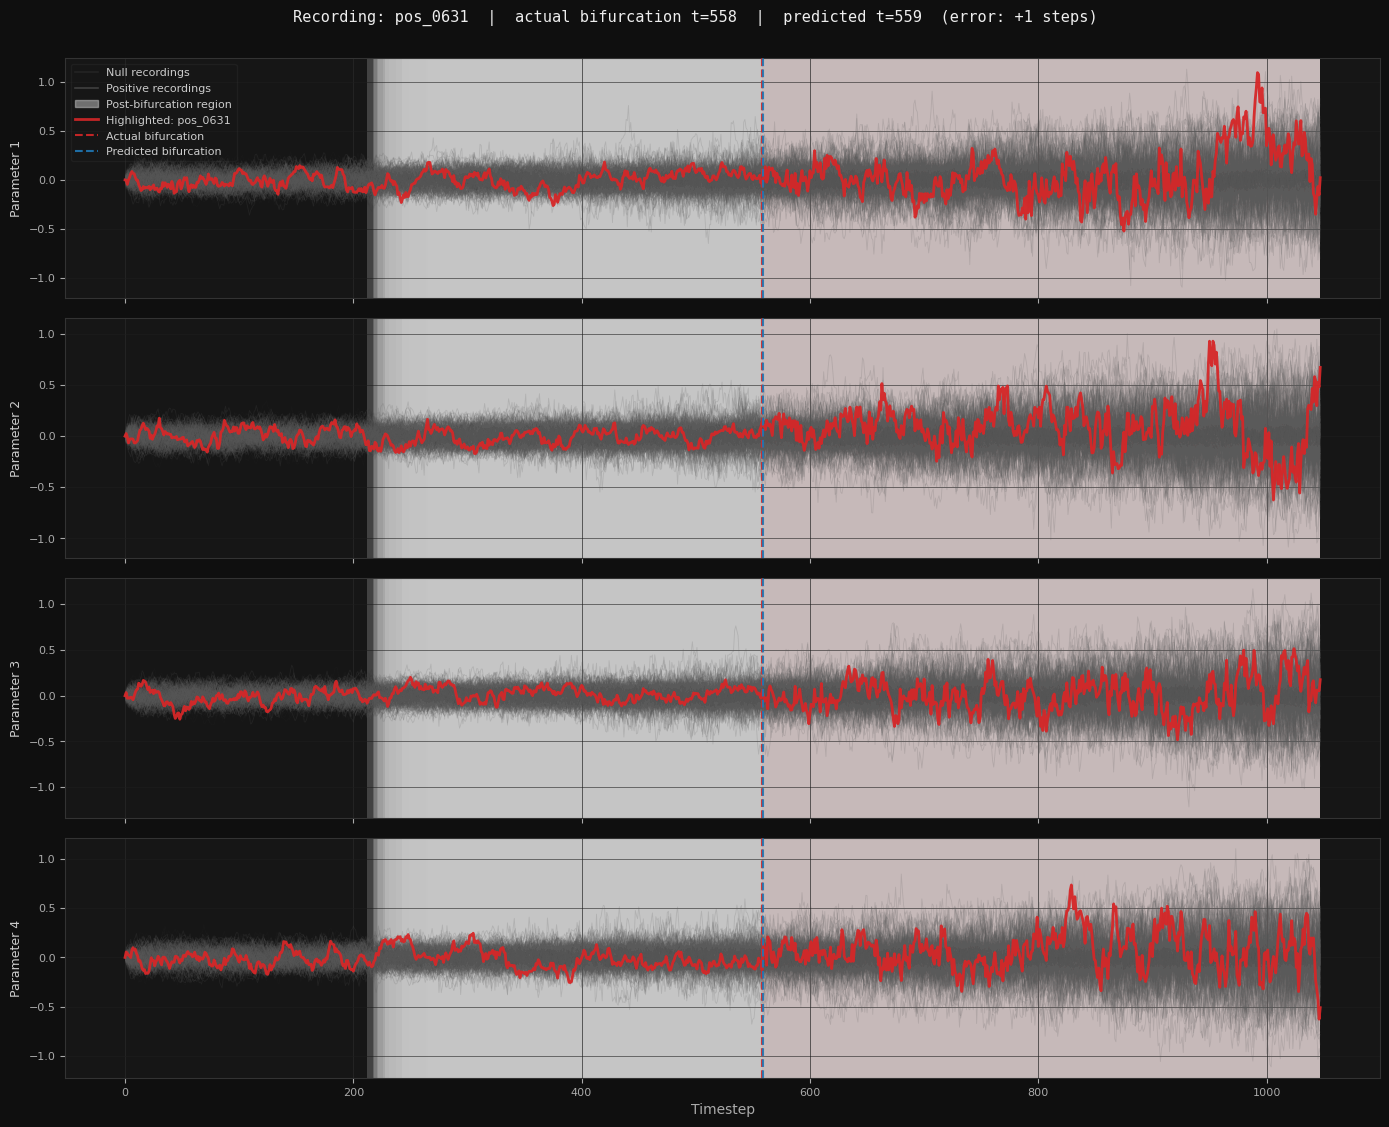

In [8]:
# ── 6. Plot recordings ─────────────────────────────────────────────────
plot_recordings(
    recordings=test_recs,
    highlight=rec,
    predicted_t=alert.predicted_bifurc_t,
    depth_summary="mean",
    param_names=["Parameter 1", "Parameter 2", "Parameter 3", "Parameter 4"],
    save_path="bifurcation_plot.png",
)

